# Code to fix your flat

This code is basically set up as a notebook style of the flat making process, and goes through each step, ending at the traces for the order. 

In [29]:
# import 
import sys
import os
import argparse
import configparser
from pathlib import Path
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import scipy.linalg
import scipy.ndimage
import astropy.io.fits as fits

sys.path.append(str(Path.cwd().parents[1]))
from kahe.calibration.make_flat import combine_flats, trace_edges, fit_and_divide
from kahe.utils.math import robust_polyfit, fit_gaussian
from kahe.instruments import nirspec

In [30]:
# === CONSTANTS ===
N = nirspec.N
RIGHT_MARGIN = nirspec.RIGHT_MARGIN
LEFT_MARGIN = nirspec.LEFT_MARGIN 
FLAT_MIN = nirspec.FLAT_MIN
FLAT_MAX = nirspec.FLAT_MAX 
MIN_ORDER_SEPARATION = nirspec.MIN_ORDER_SEPARATION
OVERSCAN_WIDTH = nirspec.OVERSCAN_WIDTH
FILTER = nirspec.NIRSPEC1_70
MIN_FRAMES = 3

In [31]:
# Set the datta directory
flats_dir = "../../../KOI7368_260704/raw/flats"
flats = [fits.getdata(f) for f in Path(flats_dir).glob("*.fits")]
print(f"Loaded {len(flats)} flat frames from {flats_dir}")

Loaded 20 flat frames from ../../../KOI7368_260704/raw/flats


In [32]:
# Set the dark directory 
master_dark =  "../../../KOI7368_260704/cals/KOI7368_260704_masterdark.fits"
with fits.open(Path(master_dark)) as hdul:
    dark_data = hdul[0].data
    dark_header = hdul[0].header

In [33]:
# Combine the flats to visualize the traces 

flat, _ = combine_flats(flats_dir, 
                        masterdark = dark_data)

Processing 20 flat frames...
   [1/20] nspec260724_0013.fits
   [2/20] nspec260724_0020.fits
   [3/20] nspec260724_0023.fits
   [4/20] nspec260724_0012.fits
   [5/20] nspec260724_0025.fits
   [6/20] nspec260724_0016.fits
   [7/20] nspec260724_0015.fits
   [8/20] nspec260724_0017.fits
   [9/20] nspec260724_0026.fits
   [10/20] nspec260724_0021.fits
   [11/20] nspec260724_0022.fits
   [12/20] nspec260724_0014.fits
   [13/20] nspec260724_0008.fits
   [14/20] nspec260724_0024.fits
   [15/20] nspec260724_0018.fits
   [16/20] nspec260724_0019.fits
   [17/20] nspec260724_0010.fits
   [18/20] nspec260724_0011.fits
   [19/20] nspec260724_0007.fits
   [20/20] nspec260724_0009.fits
Combined 20 flat frames


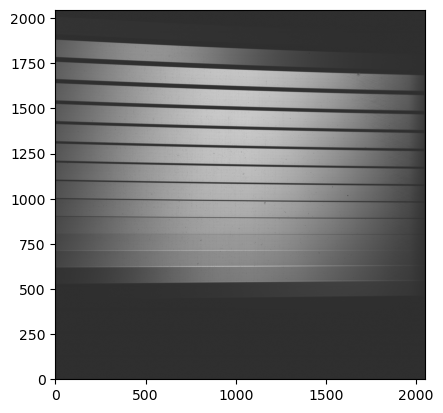

In [34]:
# Imshow the flat
plt.imshow(flat, cmap='gray', origin='lower')

# Great now trace the edges

In [35]:
def trace_edge(image, y_at_center, lower_edge=False, right_margin=30, window=10):
    edges = scipy.ndimage.sobel(image, axis=0)
    if lower_edge: edges *= -1
    edges[edges < 0] = 0
    edges[0:OVERSCAN_WIDTH + 2] = 0
    columns = np.arange(image.shape[1])
    edge_positions = np.ma.MaskedArray(np.zeros(len(columns)))

    prev_pos = y_at_center
    for c in np.arange(int(image.shape[1]/2), image.shape[1]):
        if c > len(columns) - right_margin: 
            edge_positions[c] = np.ma.masked
            continue

        y_lower = max(0, int(prev_pos - window))
        y_upper = min(int(prev_pos + window), image.shape[0] - 1)
        ys = np.arange(y_lower, y_upper)
        
        try:
            coeffs, _, gaussian = fit_gaussian(ys, edges[y_lower : y_upper, c])
            if np.abs(coeffs[1] - prev_pos) > 1 and c != int(image.shape[1]/2):
                edge_positions[c] = np.ma.masked
                continue
            
            edge_positions[c] = coeffs[1]
            prev_pos = edge_positions[c]
        except RuntimeError:
            edge_positions[c] = np.ma.masked

    prev_pos = y_at_center
    for c in np.arange(int(image.shape[1]/2), 0, -1):
        y_lower = max(0, int(prev_pos - window))
        y_upper = min(int(prev_pos + window), image.shape[0] - 1)
        ys = np.arange(y_lower, y_upper)
        
        try:
            coeffs, _, gaussian = fit_gaussian(ys, edges[y_lower : y_upper, c])
            if np.abs(coeffs[1] - prev_pos) > 1 and c != int(image.shape[1]/2):
                edge_positions[c] = np.ma.masked
                continue
            
            edge_positions[c] = coeffs[1]
            prev_pos = edge_positions[c]
        except RuntimeError:
            edge_positions[c] = np.ma.masked
            
    #plt.plot(columns, edge_positions)
    
    fitted_edge_positions = robust_polyfit(columns, edge_positions, 2)
    '''plt.imshow(image)
    plt.axhline(y_lower, color='black')
    plt.axhline(y_upper, color='black')
    if lower_edge:
        plt.plot(fitted_edge_positions, color='g')
    else:
        plt.plot(fitted_edge_positions, color='r')
    plt.show()'''

    return fitted_edge_positions

In [42]:
def trace_edges(masterflat, FILTER=None, window=10, percentile=98, 
                show_plots=True, orders=None):
    """Trace spectral order edges in the master flat.
    
    Arguments:
        masterflat: Master flat frame
        FILTER: Optional filter bounds tuple (upper, lower)
        window: Window size for edge detection
        percentile: Percentile threshold for peak finding
        show_plots: If True, display diagnostic plots
        orders: Which orders to trace. Options:
            - None (default): trace all detected orders
            - int: trace single order by index (e.g., -3 for third from end)
            - list of ints: trace specific orders by indices (e.g., [0, 2, 5])
            - "all": explicitly trace all orders
        
    Returns:
        upper_edges: Array of upper edge traces
        lower_edges: Array of lower edge traces
    """
    print('Tracing edges...')
    
    if FILTER is None:
        # Detect edges along the vertical (spatial) axis
        edges = scipy.ndimage.sobel(masterflat, axis=0)
        edges[0:OVERSCAN_WIDTH + 2] = 0  # Remove overscan rows

        # Compute the vertical profile at the center columns
        midsection = np.median(edges[:, int(N/2 - window) : int(N/2 + window)], axis=1)
        quarter_section_left = np.median(edges[:, int(N/4 - window) : int(N/4 + window)], axis=1)
        quarter_section_right = np.median(edges[:, int(N*3/4 - window) : int(N*3/4 + window)], axis=1)

        upper_positions_mid = scipy.signal.find_peaks(midsection,
                                                  height=np.percentile(midsection, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]
        lower_positions_mid = scipy.signal.find_peaks(-midsection,
                                                  height=np.percentile(-midsection, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]
        upper_positions_left = scipy.signal.find_peaks(quarter_section_left,
                                                  height=np.percentile(quarter_section_left, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]
        lower_positions_left = scipy.signal.find_peaks(-quarter_section_left,
                                                  height=np.percentile(-quarter_section_left, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]

        upper_positions_right = scipy.signal.find_peaks(quarter_section_right,
                                                  height=np.percentile(quarter_section_right, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]
        lower_positions_right = scipy.signal.find_peaks(-quarter_section_right,
                                                  height=np.percentile(-quarter_section_right, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]

        if show_plots: 
            plt.figure(figsize=(12, 6))
            plt.imshow(masterflat, origin='lower', aspect='auto', cmap='gray')
            plt.title("Master Flat with Edge Traces")
            plt.colorbar(label='Counts')

            #Plot the detected edge positions
            for pos in upper_positions_mid:
                plt.axhline(pos, color='lime', linestyle='--', lw=1)
            for pos in lower_positions_mid:
                plt.axhline(pos, color='magenta', linestyle='--', lw=1)
            for pos in upper_positions_left:
                plt.axhline(pos, color='cyan', linestyle='--', lw=1)
            for pos in lower_positions_left:
                plt.axhline(pos, color='blue', linestyle='--', lw=1)
            for pos in upper_positions_right:
                plt.axhline(pos, color='orange', linestyle='--', lw=1)
            for pos in lower_positions_right:
                plt.axhline(pos, color='red', linestyle='--', lw=1)

            plt.xlabel("X (columns)")
            plt.ylabel("Y (rows)")
            plt.tight_layout()
            plt.show()

    #     print(f"  Found {len(upper_positions)} upper positions: {upper_positions}")
    #     print(f"  Found {len(lower_positions)} lower positions: {lower_positions}")
        
    #     if show_plots:
    #         plt.figure(figsize=(12, 6))
    #         plt.imshow(masterflat, origin='lower', aspect='auto', cmap='gray')
    #         plt.title("Master Flat with Edge Traces")
    #         plt.colorbar(label='Counts')

    #         for pos in upper_positions:
    #             plt.axhline(pos, color='lime', linestyle='--', lw=1)
    #         for pos in lower_positions:
    #             plt.axhline(pos, color='magenta', linestyle='--', lw=1)

    #         plt.xlabel("X (columns)")
    #         plt.ylabel("Y (rows)")
    #         plt.tight_layout()
    #         plt.show()

    # else:
    #     # Use filter bounds if provided
    #     bounds = FILTER
    #     if len(bounds) == 2:
    #         upper_positions = np.array([bounds[0]])
    #         lower_positions = np.array([bounds[1]])

    # # Determine which orders to trace
    # num_orders = min(len(upper_positions), len(lower_positions))
    
    # if orders is None or orders == "all":
    #     # Trace all detected orders
    #     order_indices = list(range(num_orders))
    # elif isinstance(orders, int):
    #     # Single order by index
    #     order_indices = [orders if orders >= 0 else num_orders + orders]
    # elif isinstance(orders, (list, tuple)):
    #     # Specific orders by indices
    #     order_indices = [idx if idx >= 0 else num_orders + idx for idx in orders]
    # else:
    #     raise ValueError(f"Invalid orders parameter: {orders}")
    
    # # Validate indices
    # for idx in order_indices:
    #     if idx < 0 or idx >= num_orders:
    #         raise ValueError(f"Order index {idx} out of range [0, {num_orders-1}]")
    
    # print(f"  Tracing {len(order_indices)} order(s): {order_indices}")
    
    # # Trace the selected orders
    # upper_edges = []
    # lower_edges = []
    
    # for o in order_indices:
    #     print(f"    Tracing order {o}...")
    #     upper_edges.append(trace_edge(masterflat, upper_positions[o], False))
    #     lower_edges.append(trace_edge(masterflat, lower_positions[o], True))

    # return np.array(upper_edges), np.array(lower_edges)

Tracing edges...


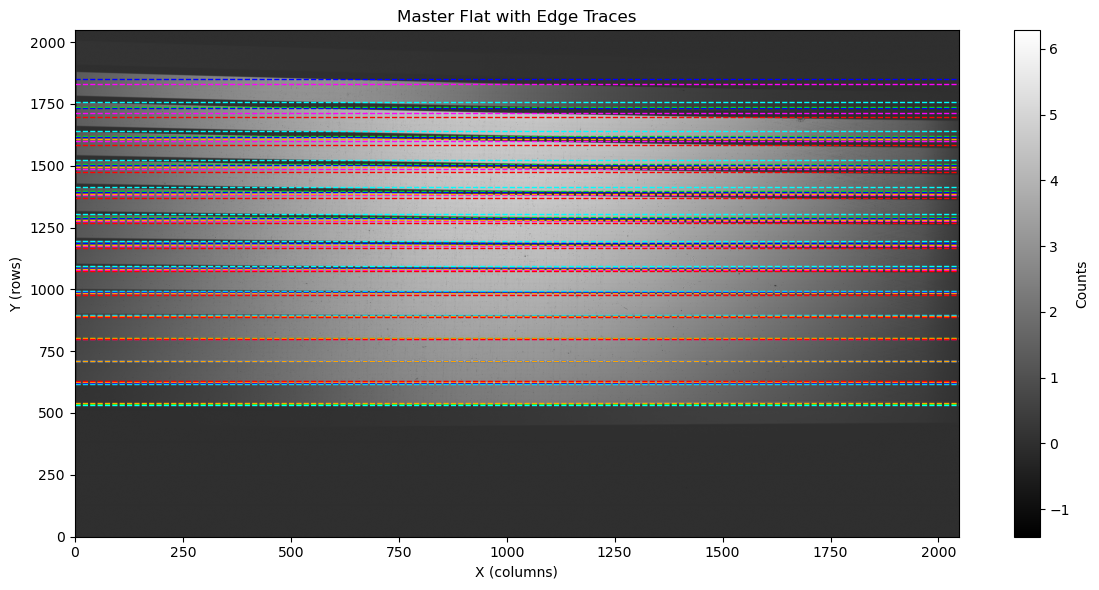

In [43]:
trace_edges(flat)

In [8]:
top_edges, bottom_edges = trace_edges(flat,
                                      FILTER=None, 
                                      show_plots=True, orders=-3)

Tracing edges...


NameError: name 'OVERSCAN_WIDTH' is not defined

As a reference, here is the order numbers in Y band from the line list: 
![here](../calibration/yband_arcs.png)

In [63]:
top_edges, bottom_edges

(array([[1543.53109918, 1543.48233783, 1543.43361026, ..., 1514.43764039,
         1514.45798228, 1514.47835796]]),
 array([[1637.40635425, 1637.3624249 , 1637.31850658, ..., 1570.60690512,
         1570.58551595, 1570.5641378 ]]))

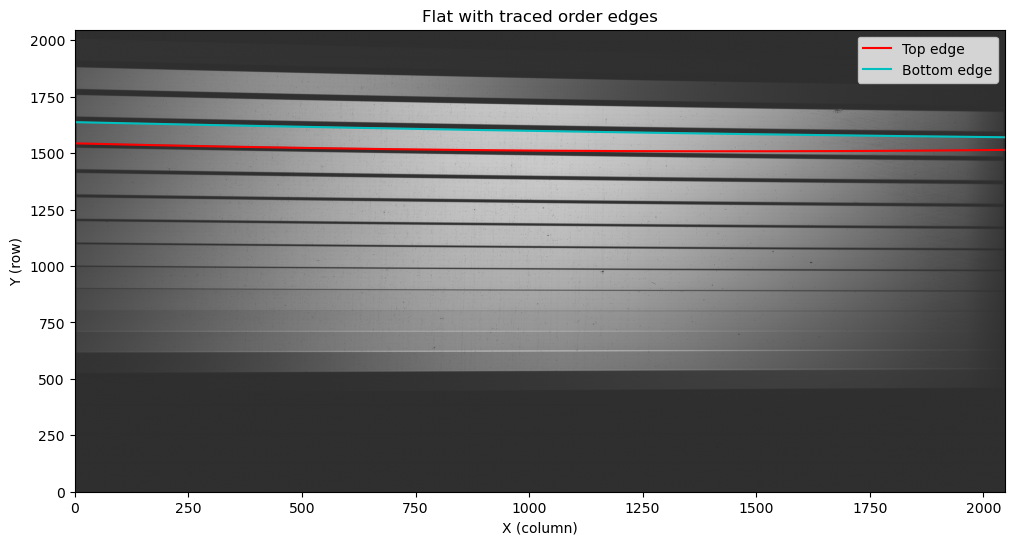

In [66]:
# Overlay traced edges on the flat
x = np.arange(flat.shape[1])  # columns

plt.figure(figsize=(12, 6))
plt.imshow(flat, cmap="gray", origin="lower", aspect="auto")

top = np.atleast_2d(top_edges)
bot = np.atleast_2d(bottom_edges)

for i in range(top.shape[0]):
    plt.plot(x, top[i], "r-", lw=1.5, label="Top edge" if i == 0 else None)
    plt.plot(x, bot[i], "c-", lw=1.5, label="Bottom edge" if i == 0 else None)

plt.xlim(0, flat.shape[1] - 1)
plt.ylim(0, flat.shape[0] - 1)
plt.legend()
plt.title("Flat with traced order edges")
plt.xlabel("X (column)")
plt.ylabel("Y (row)")
plt.show()